# Exploración del conjunto de datos
En este notebook exploraremos los datos para poder tomar una decisión sobre el diseño de la solución. En cada sección encontrarás preguntas con la intención de motivar una reflexión sobre su diseño. Mientras que no necesitan ser respondidas explícitamente, les invito a que las utilicen como guía al momento de justificar sus decisiones de diseño y presentar sus resultados.

## Datos de entrenamiento
En el conjunto de datos tenemos información sobre las *compras* realizadas en una tienda de ropa en linea. En la siguiente celda podemos ver las columnas o atributos que tenemos a nuestra disposición.
- ¿Tenemos valores faltantes o todas las columans tienen la información completa? Hay valores faltantes en las columnas custom_gender, item_avg_rating y purchase_item_rating.
- ¿Qué tipos de columnas tenemos y cómo podemos procesarlas? Hay 3 columnas de tipo float64, 4 tipo int64 y 11 tipo str. Las columnas tipo float o int las podemos procesar con normalización gaussiana o min-max, o si ya están dentro de un cierto rango los podemos dejar como están y centrarnos en los valores faltantes. Las columnas str las podemos procesar con ordinal encoding, one hot encoding, hash encoding o multilabel encoding según cómo estén los datos, habría que analizar más a fondo para ver cuál convendría más. Si son columnas de texto muy grandes como descripciones de productos, podríamos procesar esas columnas con técnicas como TF-IDF.

In [3]:
import pandas as pd
import os
from pathlib import Path
CURRENT_FILE = Path("./").resolve()
DATA_DIR = CURRENT_FILE.parent / "../datasets/customer_purchases/"
print(DATA_DIR)

train_file = DATA_DIR / "customer_purchases_train.csv"
train_file = os.path.abspath(train_file)
train_df = pd.read_csv(train_file)
train_df.columns.values[0] = "purchase_id"

train_df.info()
train_df.columns


D:\proyectos\ML26_PXNDX_MADERO\src\ml26\proyectos\..\datasets\customer_purchases
<class 'pandas.DataFrame'>
RangeIndex: 6892 entries, 0 to 6891
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   purchase_id             6892 non-null   int64  
 1   customer_id             6892 non-null   str    
 2   customer_date_of_birth  6892 non-null   str    
 3   customer_gender         5428 non-null   str    
 4   customer_signup_date    6892 non-null   str    
 5   item_id                 6892 non-null   str    
 6   item_title              6892 non-null   str    
 7   item_category           6892 non-null   str    
 8   item_price              6892 non-null   float64
 9   item_img_filename       6892 non-null   str    
 10  item_avg_rating         6798 non-null   float64
 11  item_num_ratings        6892 non-null   int64  
 12  item_release_date       6892 non-null   str    
 13  purchase_timestamp     

Index(['purchase_id', 'customer_id', 'customer_date_of_birth',
       'customer_gender', 'customer_signup_date', 'item_id', 'item_title',
       'item_category', 'item_price', 'item_img_filename', 'item_avg_rating',
       'item_num_ratings', 'item_release_date', 'purchase_timestamp',
       'customer_item_views', 'purchase_item_rating', 'purchase_device',
       'label'],
      dtype='str')

## Prueba
Recuerda que en prueba queremos saber si un cliente existente comprará un produco *no existente*. En el conjunto anterior tenemos columnas que solo tendrán información si se ha generado una compra, ¿Que columnas son estas?Las de item_avg_rating, item_num_ratings, purchase_timestamp, cutomer_item_views, purchase_item_rating y purchase_device ¿Que valores podríamos esperar de las mismas para productos que no han salido a la venta? Valores nulos o cero ¿Tiene sentido usarlas en entrenamiento tal cual?No ¿Podemos extraer información valiosa de las mismas?Sí, podemos extraer datos que nos indiquen la "popularidad" del producto.

In [12]:
import pandas as pd
import os
test_file = DATA_DIR / "customer_purchases_test.csv"
test_file = os.path.abspath(test_file)
test_df = pd.read_csv(test_file)
test_df.columns.values[0] = "purchase_id"

test_df.info()
test_df.columns

<class 'pandas.DataFrame'>
RangeIndex: 4719 entries, 0 to 4718
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   purchase_id             4719 non-null   int64  
 1   customer_id             4719 non-null   str    
 2   customer_date_of_birth  4719 non-null   str    
 3   customer_gender         3728 non-null   str    
 4   customer_signup_date    4719 non-null   str    
 5   item_id                 4719 non-null   str    
 6   item_title              4719 non-null   str    
 7   item_category           4719 non-null   str    
 8   item_price              4719 non-null   float64
 9   item_img_filename       4719 non-null   str    
 10  item_avg_rating         0 non-null      float64
 11  item_num_ratings        0 non-null      float64
 12  item_release_date       4719 non-null   str    
 13  purchase_timestamp      0 non-null      float64
 14  customer_item_views     0 non-null      float64
 15

Index(['purchase_id', 'customer_id', 'customer_date_of_birth',
       'customer_gender', 'customer_signup_date', 'item_id', 'item_title',
       'item_category', 'item_price', 'item_img_filename', 'item_avg_rating',
       'item_num_ratings', 'item_release_date', 'purchase_timestamp',
       'customer_item_views', 'purchase_item_rating', 'purchase_device'],
      dtype='str')

# Visualizar los datos por etiqueta

Visualiza las etiquetas del conjunto de datos de entrenamiento

In [13]:
byCostumerTest = test_df["customer_id"].value_counts()
print(byCostumerTest.describe())

count    779.000000
mean       6.057766
std        2.624386
min        1.000000
25%        4.000000
50%        6.000000
75%        8.000000
max       15.000000
Name: count, dtype: float64


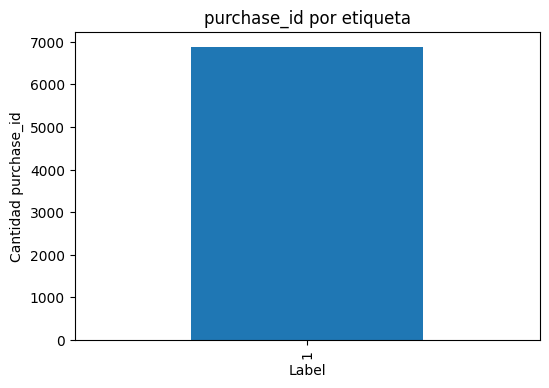

In [4]:
import matplotlib.pyplot as plt

train_df["label"].value_counts().plot(
    kind="bar",
    xlabel="Label",
    ylabel="Cantidad purchase_id",
    title="purchase_id por etiqueta",
    figsize=(6,4)
)
plt.show()

¿Notas algo extraño?  ¿Podemos entrenar un algoritmo de ML en este dataset tal cual se nos presenta?
¿Qué problemas podríamos encontrarnos?
El dataset de entrenamiento únicamente tiene registros de COMPRAS, lo que, en otras palabras, solo tenemos datos de cosas que sí compraron los clientes.
Ya que queremos hacer un modelo para predecir si un cliente comprará cierto producto, el tener datos de compras que sí se hicieron es un gran problema porque el modelo no sabrá qué compras no se harán si nunca vió un registro de ese tipo.

## Visualizar estadisticas por producto y por cliente

En el dataset solo tenemos información de las *compras*, es decir cada que se repite un `customer_id`, podemos saber cuantas compras ha hecho ese cliente. De la misma manera, contar cuantas veces se repite un `item_id` nos dice cuantas veces se ha comprado ese producto. Utiliza pandas para ver si existen clientes que compran que mayor frecuencia que otros, o productos que se compran mas que otros. Responde:
- ¿Consideras que los datos se encuentran balanceados dada la información anterior? Sí. 
- ¿Qué estrategías podrian ser útiles al momento de generar negativos? Por cada cliente, tener un vector de cosas que sí compró, luego crear un vector que contenga todos los items disponibles. Para cada registro de compra de cada cliente, asignar 5 negativos teniendo en cuenta los items que no compró. Podrían ser items populares que aún así el cliente no compró, items relacionados en categoría que el cliente no compró, o simplemente tomar de forma random 5 items que el cliente no compró.

### Datos por usuario

In [5]:
# Conteo de compras por cliente
by_customer = train_df["customer_id"].value_counts()
print(by_customer.describe())


count    779.000000
mean       8.847240
std        5.670564
min        1.000000
25%        4.000000
50%        8.000000
75%       13.000000
max       27.000000
Name: count, dtype: float64


¿Cómo podemos interpretar la información anterior?
Que el promedio de compras por cliente es de casi 9.
La varianza es de 5.67, osea si hay una varianza notable.
El clientes con menos compras hizo 1 compra.
El 25% de los cleintes hizo 4 compras o menos
El 50% de los clientes hizo 8 compras o menos
El 75% de los clientes hizo 13 compras o menos.
EL clientes con más compras tiene en total 27 compras.
Visualicemos ahora en una gráfica

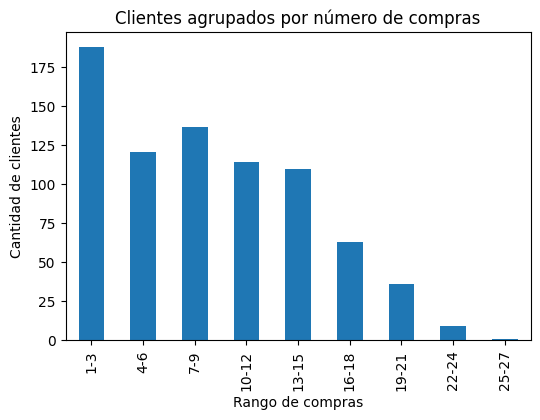

In [6]:
max_val = by_customer.max()
nbuckets = 7
increment = max_val // nbuckets

bins = []
labels = []
bins = list(range(0, max_val + increment, increment))
labels = [f"{bins[i]+1}-{bins[i+1]}" for i in range(len(bins)-1)]


customer_by_purchase = train_df['customer_id'].value_counts()
customer_buckets = pd.cut(customer_by_purchase, bins=bins, labels=labels)
bucket_counts = customer_buckets.value_counts().sort_index()

bucket_counts.plot(kind="bar", figsize=(6,4))
plt.title("Clientes agrupados por número de compras")
plt.xlabel("Rango de compras")
plt.ylabel("Cantidad de clientes")
plt.show()

### Datos por item

In [7]:
# Conteo de compras por producto
by_item = train_df["item_id"].value_counts()
print(by_item.describe())


count    485.000000
mean      14.210309
std        5.143508
min        1.000000
25%       12.000000
50%       15.000000
75%       18.000000
max       28.000000
Name: count, dtype: float64


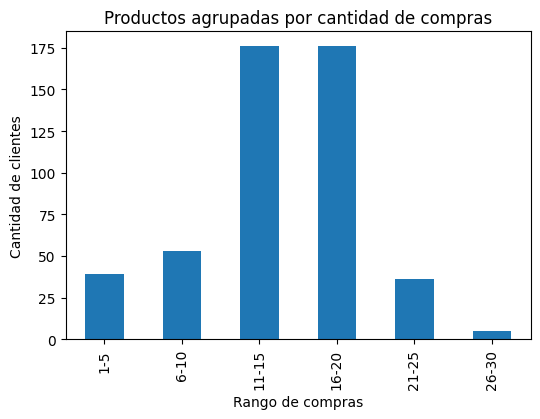

In [9]:
max_val = by_item.max()
nbuckets = 5
increment = max_val // nbuckets

bins = []
labels = []
bins = list(range(0, max_val + increment, increment))
labels = [f"{bins[i]+1}-{bins[i+1]}" for i in range(len(bins)-1)]


items_by_purchase = train_df['item_id'].value_counts()
item_buckets = pd.cut(items_by_purchase, bins=bins, labels=labels)
item_counts = item_buckets.value_counts().sort_index()

item_counts.plot(kind="bar", figsize=(6,4))
plt.title("Productos agrupadas por cantidad de compras")
plt.xlabel("Rango de compras")
plt.ylabel("Cantidad de clientes")
plt.show()

# Generación ejemplos negativos

Como pudiste notar solo tenemos información de compras. Si se deseara realizar un algoritmo de clasificación para productos nuevos, este fallaría al ser entrneado en el dataset original ya que no tendría información de ejemplos negativos. Por lo anterior, este tipo de problemas comunmente se modela como sistemas de recomendación. 

Otra manera de resolverlo, es generar ejemplos negativos dada la información en el conjunto, por ejemplo sabemos el inventario completo (los `item_id` únicos) y sus atributos, asi como el conjunto completo de clientes (`customer_id` únicos) y para cada cliente sabemos los productos que han comprado, *pero tambien sabemos los que no compraron* si al conjunto de productos completo, le restamos el conjunto de productos que si compró. Esto nos da una señal de ejemplos negativos que podemos usar para clasificación.

Dicho esto tienes 2 opciones:
1. Investigar sistemas de recomendación tradicionales [(collaborative filtering, content-based filtering etc)](https://www.geeksforgeeks.org/machine-learning/content-based-vs-collaborative-filtering-difference/)
2. Modelaro como un sistema de clasificación y generar tus propios ejemplos negativos

Son libres de elegir la decisión que prefieran.

En el caso de clasificación tenemos que considerar lo siguiente: Para muchos clientes, el conjunto de items no comprados será mucho mayor que el de items comprados. 
- ¿Qué problemas puedo tener si elijo como negativos todos los no comprados para todos los clientes?
- ¿Pueden pensar en diferentes estrategias para generar los negativos?

Pueden utilizar el archivo [negative_generation.py](./negative_generation.py) para implementar diferentes estrategias de generación de negativos. 

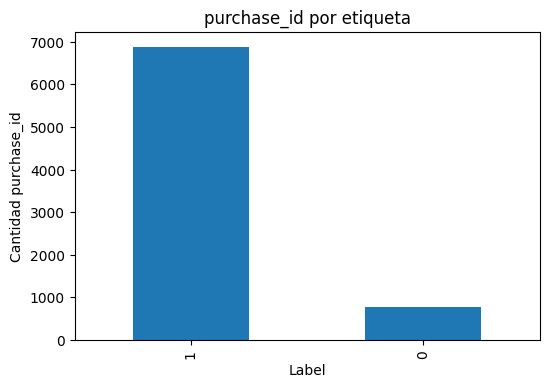

In [10]:
from ml26.proyectos.P02_customer_purchases.pipeline.negatives import gen_uniform_random, gen_random_negatives

train_df_neg = gen_random_negatives(train_df,n_per_positive=1)

train_df_full = pd.concat((train_df, train_df_neg))
# Shuffle para que cuando hagamos el split tengamos de ambos muestras
train_df_full = train_df_full.sample(frac=1) # 100%

train_df_full["label"].value_counts().plot(
    kind="bar",
    xlabel="Label",
    ylabel="Cantidad purchase_id",
    title="purchase_id por etiqueta",
    figsize=(6,4)
)
plt.show()

- ¿Que podemos observar cuando generamos todos los negativos?
- ¿Se les ocurre otra manera de elegirlos?

d:\proyectos\ML26_PXNDX_MADERO\.venv\Scripts\python.exe: No module named pip


Note: you may need to restart the kernel to use updated packages.


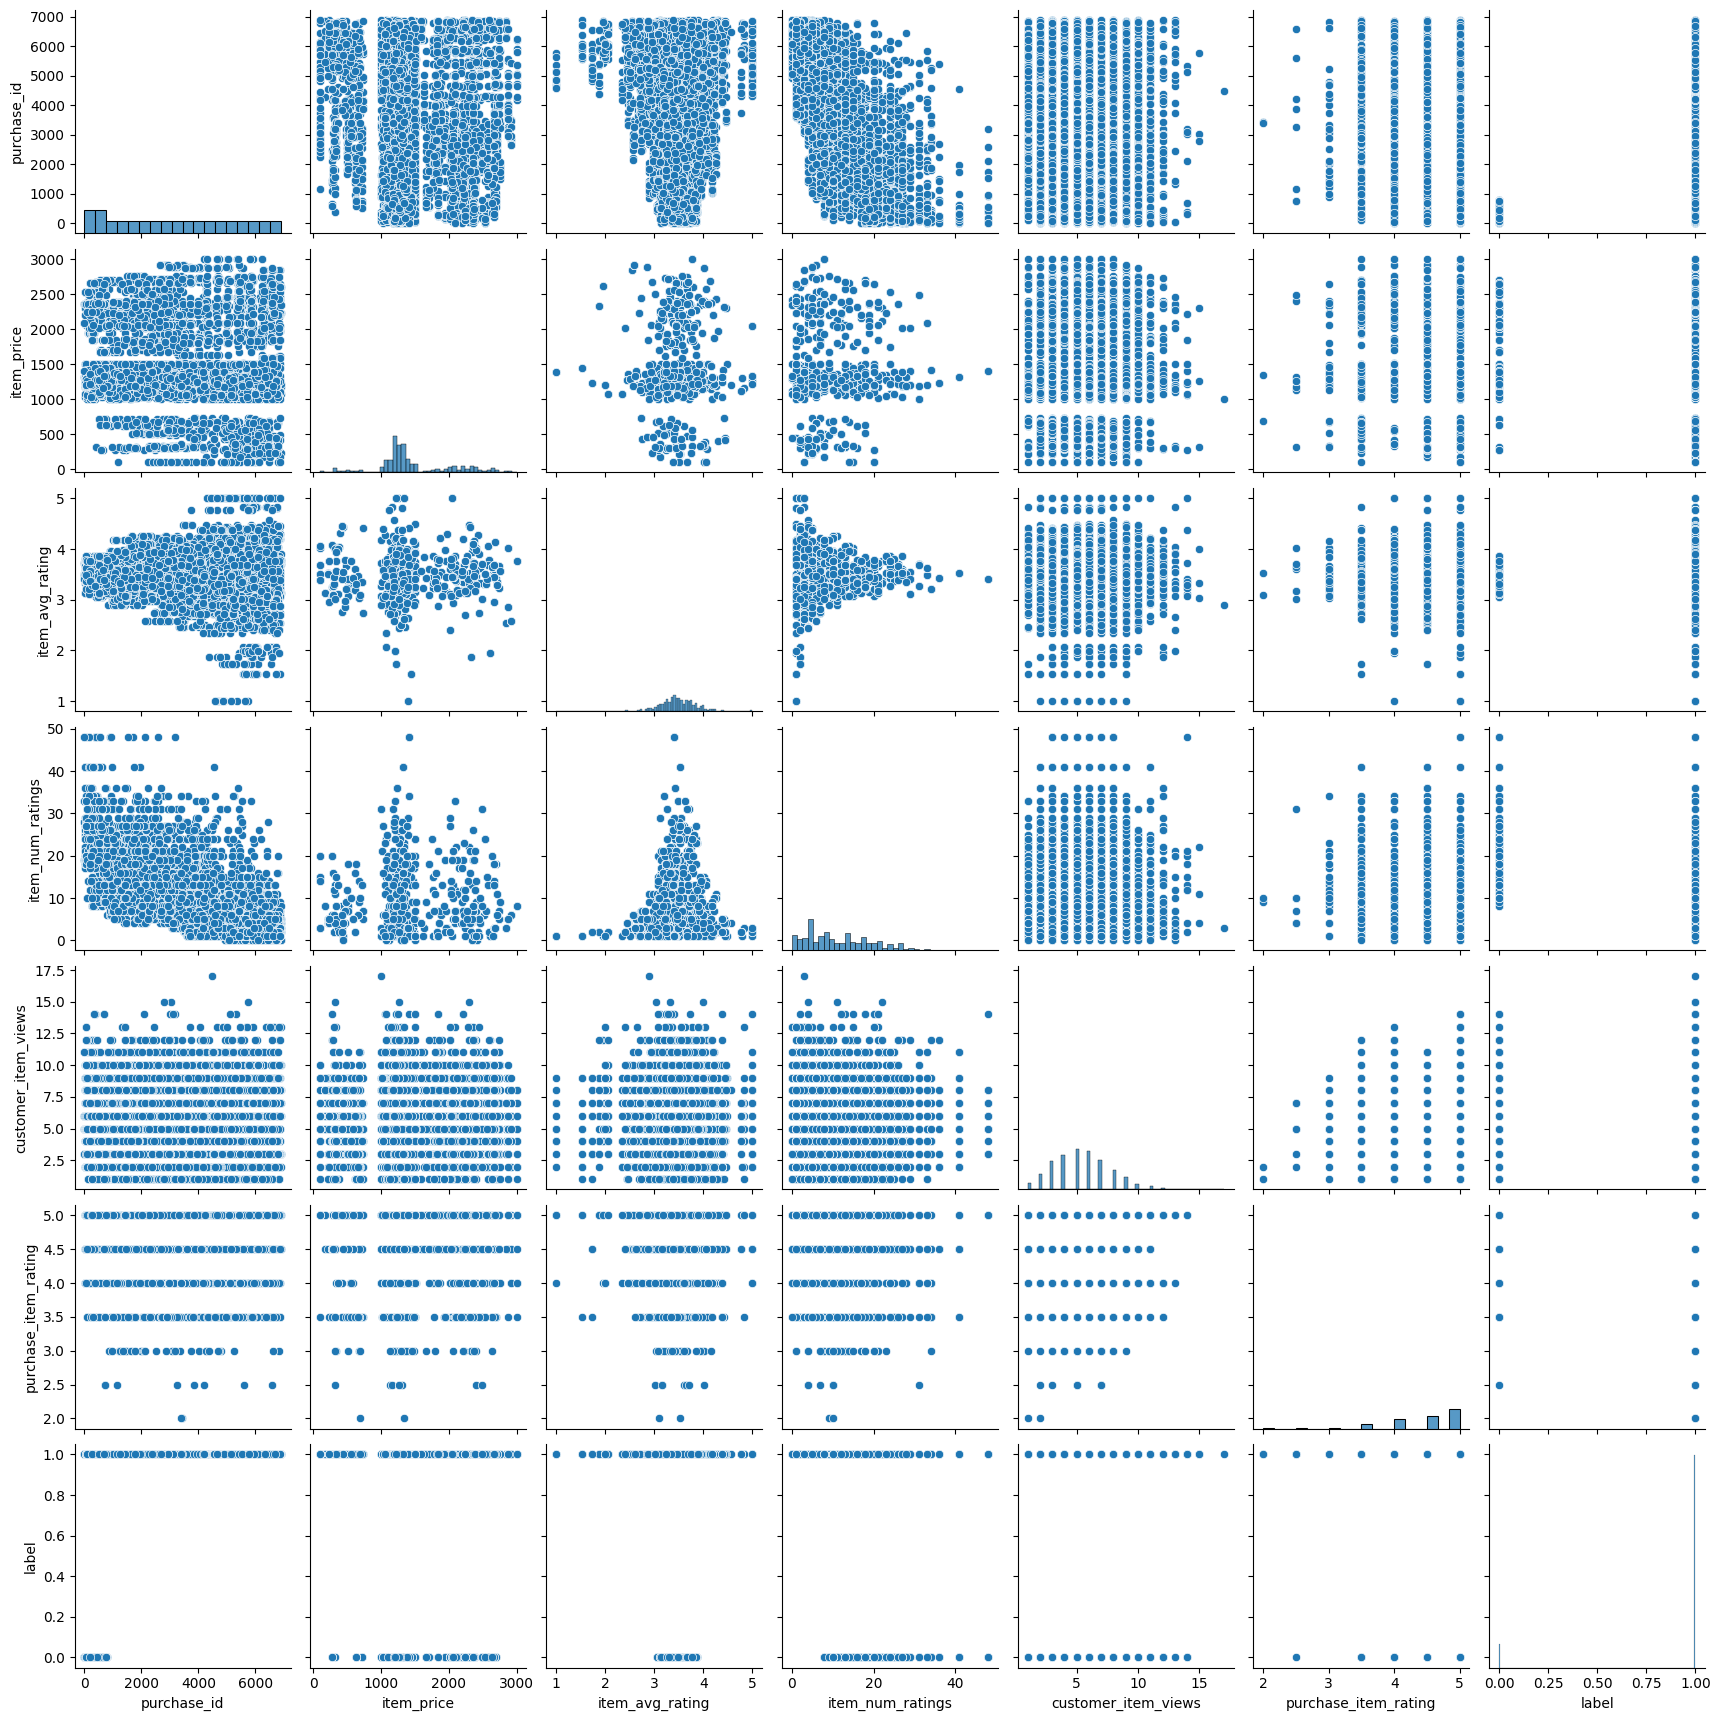

In [11]:
%pip install seaborn
import seaborn as sns
sns.pairplot(train_df_full)

## Entregables: Análisis exploratorio
Dentro de sus entregables de analisis, intenten responder a las preguntas:
- ¿Existen valores faltantes (i.e. NaN / None)? ¿Como proponen manejarlos?
- ¿Que atributos pueden ser predictores útiles?
- ¿Tenemos etiquetas balanceadas? ¿Cómo van a manejarlas? ¿Cómo la decisión de cómo generar los negativos afecta al desvalance?
- ¿Que cantidad de productos existententes vs. nuevos tenemos?
- ¿Cuantos clientes tenemos?
- ¿Que tipos de datos tenemos y como podemos procesarlos?
- ¿Existen correlaciones fuertes entre variables dependientes?
- ¿Que correlaciones pueden ver entre las variables dependientes y la independiente?

### Bonus:
Se otorgarán puntos extra a análisis exploratorios excepcionales que integren diferentes métodos de ML visualizaciones y reconocimientos de patrones más complejos que vayan mas allá de lo propuesto/observado en este notebook.

### Recomendaciones generales
- Les recomiendo explorar la libreria de [seaborn](https://seaborn.pydata.org/) y las diferentes opciones de visualización que tienen.
- Los resultados de este problema dependen en gran medida de los atributos derivados y manejo de datos por lo que les recomiento invertir la mayoría de su tiempo a explorar entrenamiento con diferentes conjuntos de atributos.

## Extracción de atributos

Podemos extraer atributos del cliente para utilizar tanto en entrenamiento como validación o prueba. utilicen las celdas de abajo para lo mismo y guardar los datos en `customer_feat.csv`. Posteriormente podemos usar estos atributos junto con los de los items existentes asi como nuevos para entrenar y posteriormente predecir.

Puedes reemplazar tu eleccion de extracción de atributos en [data_processing.py -> extract_customer_features](./data_processing.py)

In [ ]:
import pandas as pd
import numpy as np
from ml26.proyectos.P02_customer_purchases.pipeline.io import read_csv, DATA_COLLECTED_AT

train_df = read_csv("customer_purchases_train")
print(train_df.columns)

In [ ]:
# date columns
train_df['item_release_date'] = pd.to_datetime(train_df['item_release_date'])
train_df['purchase_timestamp'] = pd.to_datetime(train_df['purchase_timestamp'])
train_df['customer_date_of_birth'] = pd.to_datetime(train_df['customer_date_of_birth'])
train_df['customer_signup_date'] = pd.to_datetime(train_df['customer_signup_date'])

# --- Usa estas celdas para experimentar tratando de generar diferentes atributos que podrían ser útiles---
# E.g.: days since release at purchase
train_df['purchase_days_since_release'] = (train_df['purchase_timestamp'] - train_df['item_release_date']).dt.days
neg_count = (train_df['purchase_days_since_release'] < 0).sum()
print(f"Negative days_since_release: {neg_count}")


In [ ]:
items = train_df['item_id'].unique()
print(len(items), "total items")

categories = train_df['item_category'].unique()
print(len(items), "total categories")
print(categories)